In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from pandas.core.common import random_state
from sklearn.linear_model import LinearRegression

df = pd.read_csv("Salary_Data.csv")
print(df.head())
print(df.info())
print(df.shape)
print(df.describe())

   YearsExperience   Salary
0              1.1  39343.0
1              1.3  46205.0
2              1.5  37731.0
3              2.0  43525.0
4              2.2  39891.0
<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes
None
(30, 2)
       YearsExperience         Salary
count        30.000000      30.000000
mean          5.313333   76003.000000
std           2.837888   27414.429785
min           1.100000   37731.000000
25%           3.200000   56720.750000
50%           4.700000   65237.000000
75%           7.700000  100544.750000
max          10.500000  122391.000000


In [6]:
X = df[["YearsExperience"]]
print(X)

    YearsExperience
0               1.1
1               1.3
2               1.5
3               2.0
4               2.2
5               2.9
6               3.0
7               3.2
8               3.2
9               3.7
10              3.9
11              4.0
12              4.0
13              4.1
14              4.5
15              4.9
16              5.1
17              5.3
18              5.9
19              6.0
20              6.8
21              7.1
22              7.9
23              8.2
24              8.7
25              9.0
26              9.5
27              9.6
28             10.3
29             10.5


In [7]:
y = df["Salary"]
print(y)

0      39343.0
1      46205.0
2      37731.0
3      43525.0
4      39891.0
5      56642.0
6      60150.0
7      54445.0
8      64445.0
9      57189.0
10     63218.0
11     55794.0
12     56957.0
13     57081.0
14     61111.0
15     67938.0
16     66029.0
17     83088.0
18     81363.0
19     93940.0
20     91738.0
21     98273.0
22    101302.0
23    113812.0
24    109431.0
25    105582.0
26    116969.0
27    112635.0
28    122391.0
29    121872.0
Name: Salary, dtype: float64


In [8]:
print(X.head())
print(y.head())

   YearsExperience
0              1.1
1              1.3
2              1.5
3              2.0
4              2.2
0    39343.0
1    46205.0
2    37731.0
3    43525.0
4    39891.0
Name: Salary, dtype: float64


In [54]:
#split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2, 
    random_state=42
)

In [16]:
print(X_train.shape)
print(X_test.shape)

(24, 1)
(6, 1)


In [18]:
#create model
model = LinearRegression()

In [23]:
#train model
modelfit = model.fit(X_train,y_train)
print(modelfit)

LinearRegression()


In [22]:
#Predict  
y_pred = model.predict(X_test)
print(y_pred)

[115790.21011287  71498.27809463 102596.86866063  75267.80422384
  55477.79204548  60189.69970699]


In [27]:
slope = model.coef_
print(slope)

[9423.81532303]


In [28]:
intercept = model.intercept_
print(intercept)

25321.583011776813


In [36]:
salary =slope*6+intercept
print(salary)

[81864.47494996]


In [37]:
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error

mean_abs_error = mean_absolute_error(y_test,y_pred)
print("Mean Absolute Error:",mean_abs_error)

mean_sq_error = mean_squared_error(y_test,y_pred)
print("Mean Squared Error:",mean_sq_error)

Mean Absolute Error: 6286.453830757749
Mean Squared Error: 49830096.85590839


In [39]:
print("Actual Salary")
print(y_test.values)

print("\nPredicted Salary")
print(y_pred)

Actual Salary
[112635.  67938. 113812.  83088.  64445.  57189.]

Predicted Salary
[115790.21011287  71498.27809463 102596.86866063  75267.80422384
  55477.79204548  60189.69970699]


In [40]:
error = y_test.values - y_pred

print(error)

[-3155.21011287 -3560.27809463 11215.13133937  7820.19577616
  8967.20795452 -3000.69970699]


In [41]:
absolute_error = abs(error)

print(absolute_error)

[ 3155.21011287  3560.27809463 11215.13133937  7820.19577616
  8967.20795452  3000.69970699]


In [42]:
mae = absolute_error.mean()

print("MAE =", mae)

MAE = 6286.453830757749


In [45]:
squared_error = error ** 2

print(squared_error)

[9.95535086e+06 1.26755801e+07 1.25779171e+08 6.11554620e+07
 8.04108185e+07 9.00419873e+06]


In [46]:
mse = squared_error.mean()

print("MSE =", mse)

MSE = 49830096.85590839


In [47]:
rmse = mse ** 0.5

print("RMSE =", rmse)

RMSE = 7059.04362190151


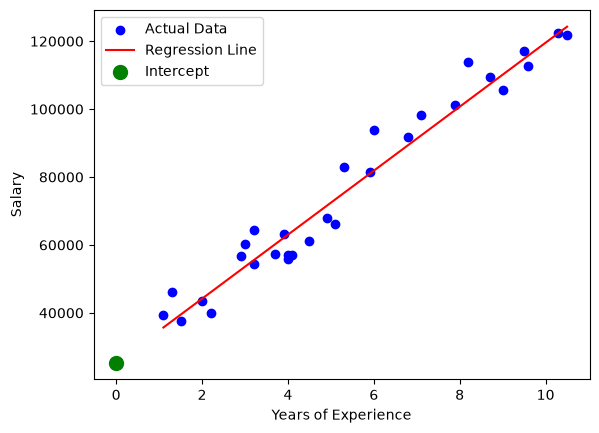

In [61]:
plt.scatter(X, y, color="blue", label="Actual Data")

predicted_salary = slope * X + intercept
plt.plot(X, predicted_salary, color="red", label="Regression Line")

plt.scatter(0, intercept, color="green", s=100, label="Intercept")

plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.legend()
plt.show()